# Phase 4: Shifted evaluation

This is where we actually answer the research question. Pull Tran et al.'s MalNet-Tiny-Common dataset (the covariate shift benchmark) from HuggingFace (https://huggingface.co/datasets/nntvu/MalNet-Tiny-Features), retrain all four models from scratch, evaluate each on both the standard test set and the shifted test set.

The full HF repo is around 1 TB cause it includes huge LLM embedding variants. We only grab the structure only variant (none+none, 363 MB) so the download stays manageable on Colab.

Headline metric: robustness gap = standard accuracy minus shifted accuracy. Smaller gap means the model generalizes better. We want to see if the gating model from phase 3 has a smaller gap than the structural baseline and the zero fill or prune EnrichedGCN.


## 1. Setup


In [1]:
import os
REPO = "malnet-shift-robustness"
if not os.path.exists(REPO):
    !git clone https://github.com/AdityaRao127/malnet-shift-robustness.git
%cd $REPO


Cloning into 'malnet-shift-robustness'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 63 (delta 28), reused 62 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 171.05 KiB | 34.21 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/malnet-shift-robustness


In [2]:
!pip install -q torch-geometric==2.7.0 scikit-learn pandas matplotlib tqdm numpy huggingface_hub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.2 MB/s eta 0:00:00


In [3]:
import os, sys, time, random, json
sys.path.insert(0, "src")

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from torch_geometric.loader import DataLoader

from data_loader import load_malnet_splits
from features import make_pre_transform, ENRICHED_GROUPS
from missingness import make_missingness_transform
from model import BaselineGCN, EnrichedGCN, GatedGCN
from train import train_model, train_model_gated, predict, predict_gated, build_metrics, save_metrics
from hf_download import list_repo_files, download_common_split, get_split_root
from shift_loader import (
    load_shifted_graphs, make_shifted_loader, compute_robustness_gap,
    make_label_remap, remap_labels,
    load_split_dict, slice_to_split, node_count_stats,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")


using device: cuda


## 2. Inspect HuggingFace Repo

First, see what files are actually available so we know what patterns to download.


In [4]:
files = list_repo_files()
print(f"total files: {len(files)}")
for f in files[:30]:
    print(" ", f)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


total files: 313
  .gitattributes
  MalNetTinyFeatures/processed/prune+all+qwen_keepisolated/data.pt
  MalNetTinyFeatures/processed/prune+all+qwen_keepisolated/hash_list.pt
  MalNetTinyFeatures/processed/prune+all+qwen_keepisolated/keep_idxs_list.pt
  MalNetTinyFeatures/processed/prune+all+qwen_keepisolated/mask_list.pt
  MalNetTinyFeatures/processed/prune+all+qwen_keepisolated/pre_filter.pt
  MalNetTinyFeatures/processed/prune+all+qwen_keepisolated/pre_transform.pt
  MalNetTinyFeatures/processed/prune+all+qwen_keepisolated/split_dict.pt
  MalNetTinyFeatures/processed/prune+all+unix_keepisolated/data.pt
  MalNetTinyFeatures/processed/prune+all+unix_keepisolated/hash_list.pt
  MalNetTinyFeatures/processed/prune+all+unix_keepisolated/keep_idxs_list.pt
  MalNetTinyFeatures/processed/prune+all+unix_keepisolated/mask_list.pt
  MalNetTinyFeatures/processed/prune+all+unix_keepisolated/pre_filter.pt
  MalNetTinyFeatures/processed/prune+all+unix_keepisolated/pre_transform.pt
  MalNetTinyFeature

## 3. Download Shifted Common Split

This pulls graph structure files for the Common subset. The first run takes a few minutes depending on actual file size.


In [5]:
# only pulls the structure-only variant (none+none), avoids llm embedding files
local_path = download_common_split(local_dir="data/hf_malnet/", variant="none+none")
print(f"downloaded to: {local_path}")
common_root = get_split_root("data/hf_malnet/", variant="none+none")
print(f"common split root: {common_root}")


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

downloaded to: /content/malnet-shift-robustness/data/hf_malnet
common split root: data/hf_malnet/MalNetTinyFeaturesCommon/processed/none+none


## 4. Load Shifted Test Set

Apply the same pre_transform we used during training so feature dimensions match. Loader is non-recursive on purpose so we only read the .pt in this exact directory.


In [6]:
# enriched features for the enriched and gated models
pre_enriched = make_pre_transform(feature_type="enriched")
shifted_enriched_all = load_shifted_graphs(common_root, pre_transform=pre_enriched)
print(f"shifted enriched graphs (all): {len(shifted_enriched_all)}")
assert len(shifted_enriched_all) > 0, "shifted dataset is empty, check the HuggingFace download"

# structural features for the structural baseline
pre_structural = make_pre_transform(feature_type="structural")
shifted_structural_all = load_shifted_graphs(common_root, pre_transform=pre_structural)
print(f"shifted structural graphs (all): {len(shifted_structural_all)}")

# tran et al. ship a split_dict.pt with 3500 train / 500 val / 1000 test indices
# for fair comparison to their reported common-shifted numbers, we use just the test slice
split_dict = load_split_dict(common_root)
if split_dict is not None:
    print(f"split_dict found: train={len(split_dict['train'])}, "
          f"valid={len(split_dict['valid'])}, test={len(split_dict['test'])}")
    shifted_enriched = slice_to_split(shifted_enriched_all, split_dict["test"])
    shifted_structural = slice_to_split(shifted_structural_all, split_dict["test"])
    print(f"using {len(shifted_enriched)} graphs from common test split for evaluation")
else:
    print("no split_dict.pt found, falling back to all graphs as the shifted test set")
    shifted_enriched = shifted_enriched_all
    shifted_structural = shifted_structural_all

# node count stats (semantic features cap at 4000 nodes for memory reasons)
stats = node_count_stats(shifted_structural)
print(f"shifted node counts: {stats}")

# label space sanity check
all_labels = set()
for d in shifted_structural:
    all_labels.add(int(d.y.item()) if d.y.numel() == 1 else int(d.y.flatten()[0].item()))
print(f"shifted label values (pre remap): {sorted(all_labels)}")


shifted enriched graphs (all): 5000
shifted structural graphs (all): 5000
split_dict found: train=3500, valid=500, test=1000
using 1000 graphs from common test split for evaluation
shifted node counts: {'n': 1000, 'mean': 2192.02001953125, 'median': 1792, 'max': 4998, 'pct_over_4000': 24.100000381469727}
shifted label values (pre remap): [0, 1, 2, 3, 4]


## 4b. Fix the label ordering

The Common dataset orders its classes differently than PyG's MalNetTiny, so without a remap the shifted accuracy comes out scrambled. We build the remap once and apply it to all shifted graphs before evaluation.


In [7]:
# tran et al. common loader class order, from their malnet_tiny_features.py
COMMON_CLASS_NAMES = ["addisplay", "adware", "benign", "downloader", "trojan"]
# our standard CLASS_NAMES are derived from pyg's first-appearance order, set later

# we cannot build the remap yet because CLASS_NAMES is defined in the next cell after
# load_malnet_splits runs, so the remap is computed inline at first use below
print("standard order will be derived from data/structural/raw splits")
print(f"common order (from tran public code): {COMMON_CLASS_NAMES}")


standard order will be derived from data/structural/raw splits
common order (from tran public code): ['addisplay', 'adware', 'benign', 'downloader', 'trojan']


## 5. Retrain All Four Models on Standard Train

To compare fair, we retrain each model from scratch on the standard MalNet-Tiny train, then evaluate on both standard and shifted test sets.

(if you already trained these in earlier notebooks and saved checkpoints, you could load those instead)


In [8]:
EPOCHS = 50
LR = 0.001
BATCH_SIZE = 64
HIDDEN_DIM = 64
DROP_PROB = 0.5
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- structural baseline ---
print("=" * 50, "\nstructural baseline")
ds_train, ds_val, ds_test = load_malnet_splits(root="data/structural/", pre_transform=pre_structural)
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

m_baseline = BaselineGCN(ds_train.num_features, HIDDEN_DIM, ds_train.num_classes).to(device)
t0 = time.time()
m_baseline, _, _, best_val = train_model(m_baseline, train_loader, val_loader, EPOCHS, LR, device)
t_baseline = time.time() - t0
print(f"baseline trained in {t_baseline:.1f}s, best val {best_val:.4f}")

# helper to read class order from a populated pyg root
def _read_class_names(root):
    raw_type_dir = os.path.join(root, "raw", "split_info_tiny", "type")
    y_map = {}
    for split_file in ["train.txt", "val.txt", "test.txt"]:
        with open(os.path.join(raw_type_dir, split_file)) as f:
            for line in f.read().strip().split("\n"):
                mtype = line.split("/")[0]
                y_map.setdefault(mtype, len(y_map))
    return [name for name, _ in sorted(y_map.items(), key=lambda x: x[1])]

CLASS_NAMES = _read_class_names(os.path.join("data", "structural"))
print(f"standard classes: {CLASS_NAMES}")

# now that we have CLASS_NAMES we can build the remap and apply to shifted graphs once
label_remap = make_label_remap(COMMON_CLASS_NAMES, CLASS_NAMES)
print(f"label remap (common -> standard): {label_remap}")
remap_labels(shifted_structural, label_remap)
remap_labels(shifted_enriched, label_remap)
print("shifted labels remapped to standard class order")


structural baseline


Extracting data/structural/raw/malnet-graphs-tiny.tar.gz
Extracting data/structural/raw/split_info_tiny.zip
Processing...
Done!


  Epoch 010 | Loss: 0.8214 | Val Acc: 0.7180
  Epoch 020 | Loss: 0.7413 | Val Acc: 0.7140
  Epoch 030 | Loss: 0.6892 | Val Acc: 0.7140
  Epoch 040 | Loss: 0.6440 | Val Acc: 0.7280
  Epoch 050 | Loss: 0.6351 | Val Acc: 0.7520
baseline trained in 54.6s, best val 0.7840
standard classes: ['adware', 'benign', 'downloader', 'trojan', 'addisplay']
label remap (common -> standard): [4, 0, 1, 2, 3]
shifted labels remapped to standard class order


## 6. Evaluate Baseline on Standard and Shifted


In [9]:
# standard
preds_s, labels_s = predict(m_baseline, test_loader, device)
acc_standard = accuracy_score(labels_s, preds_s)

# shifted
shifted_loader = make_shifted_loader(shifted_structural, batch_size=BATCH_SIZE)
preds_sh, labels_sh = predict(m_baseline, shifted_loader, device)
acc_shifted = accuracy_score(labels_sh, preds_sh)

gap = compute_robustness_gap(acc_standard, acc_shifted)
print(f"baseline standard: {acc_standard:.4f}, shifted: {acc_shifted:.4f}, gap: {gap:.4f}")

# save shifted metrics
config = {"feature_type": "structural", "epochs": EPOCHS, "device": str(device)}
metrics = build_metrics(preds_sh, labels_sh, CLASS_NAMES, config, best_val, t_baseline)
metrics["robustness_gap"] = gap
metrics["accuracy_standard"] = round(float(acc_standard), 4)
save_metrics(metrics, RESULTS_DIR, prefix="baseline_shifted")

# free gpu memory before next training block
del m_baseline, train_loader, val_loader, test_loader, ds_train, ds_val, ds_test
if torch.cuda.is_available():
    torch.cuda.empty_cache()


baseline standard: 0.7460, shifted: 0.3840, gap: 0.3620


## 7. EnrichedGCN with Zero-Fill, Both Splits


In [10]:
ds_e_train, ds_e_val, ds_e_test = load_malnet_splits(root="data/enriched/", pre_transform=pre_enriched)
miss_train = make_missingness_transform(ENRICHED_GROUPS, drop_prob=DROP_PROB, strategy="zero", seed=SEED)
miss_test = make_missingness_transform(ENRICHED_GROUPS, drop_prob=0.0, strategy="zero", seed=0)
ds_e_train.transform = miss_train
ds_e_val.transform = miss_test
ds_e_test.transform = miss_test

train_loader_e = DataLoader(ds_e_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader_e = DataLoader(ds_e_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader_e = DataLoader(ds_e_test, batch_size=BATCH_SIZE, shuffle=False)

m_enriched = EnrichedGCN(ds_e_train.num_features, HIDDEN_DIM, ds_e_train.num_classes).to(device)
t0 = time.time()
m_enriched, _, _, best_val_e = train_model(m_enriched, train_loader_e, val_loader_e, EPOCHS, LR, device)
t_enriched = time.time() - t0

preds_es, labels_es = predict(m_enriched, test_loader_e, device)
acc_es = accuracy_score(labels_es, preds_es)

# shifted: apply miss_test to keep mask attribute (model does not use it but loader needs consistent batches)
for d in shifted_enriched:
    d.missingness_mask = torch.ones(1, len(ENRICHED_GROUPS))
shifted_loader_e = make_shifted_loader(shifted_enriched, batch_size=BATCH_SIZE)
preds_esh, labels_esh = predict(m_enriched, shifted_loader_e, device)
acc_esh = accuracy_score(labels_esh, preds_esh)

gap_e = compute_robustness_gap(acc_es, acc_esh)
print(f"enriched_zero standard: {acc_es:.4f}, shifted: {acc_esh:.4f}, gap: {gap_e:.4f}")

config = {"feature_type": "enriched", "missingness_strategy": "zero", "epochs": EPOCHS, "device": str(device)}
metrics = build_metrics(preds_esh, labels_esh, CLASS_NAMES, config, best_val_e, t_enriched)
metrics["robustness_gap"] = gap_e
metrics["accuracy_standard"] = round(float(acc_es), 4)
save_metrics(metrics, RESULTS_DIR, prefix="enriched_zero_shifted")

# keep enriched dataset alive for prune and gated runs, just free this model
del m_enriched
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Extracting data/enriched/raw/malnet-graphs-tiny.tar.gz
Extracting data/enriched/raw/split_info_tiny.zip
Processing...
Done!


  Epoch 010 | Loss: 1.1022 | Val Acc: 0.7000
  Epoch 020 | Loss: 1.0681 | Val Acc: 0.6200
  Epoch 030 | Loss: 1.0293 | Val Acc: 0.7280
  Epoch 040 | Loss: 0.9952 | Val Acc: 0.7240
  Epoch 050 | Loss: 0.9614 | Val Acc: 0.7760
enriched_zero standard: 0.7370, shifted: 0.4120, gap: 0.3250


## 7b. EnrichedGCN with Prune, Both Splits


In [11]:
miss_train_p = make_missingness_transform(ENRICHED_GROUPS, drop_prob=DROP_PROB, strategy="prune", seed=SEED)
ds_e_train.transform = miss_train_p

g = torch.Generator(); g.manual_seed(SEED)
train_loader_p = DataLoader(ds_e_train, batch_size=BATCH_SIZE, shuffle=True, generator=g)

m_enriched_p = EnrichedGCN(ds_e_train.num_features, HIDDEN_DIM, ds_e_train.num_classes).to(device)
t0 = time.time()
m_enriched_p, _, _, best_val_ep = train_model(m_enriched_p, train_loader_p, val_loader_e, EPOCHS, LR, device)
t_enriched_p = time.time() - t0

preds_eps, labels_eps = predict(m_enriched_p, test_loader_e, device)
acc_eps = accuracy_score(labels_eps, preds_eps)

shifted_loader_p = make_shifted_loader(shifted_enriched, batch_size=BATCH_SIZE)
preds_epsh, labels_epsh = predict(m_enriched_p, shifted_loader_p, device)
acc_epsh = accuracy_score(labels_epsh, preds_epsh)

gap_ep = compute_robustness_gap(acc_eps, acc_epsh)
print(f"enriched_prune standard: {acc_eps:.4f}, shifted: {acc_epsh:.4f}, gap: {gap_ep:.4f}")

config = {"feature_type": "enriched", "missingness_strategy": "prune", "epochs": EPOCHS, "device": str(device)}
metrics = build_metrics(preds_epsh, labels_epsh, CLASS_NAMES, config, best_val_ep, t_enriched_p)
metrics["robustness_gap"] = gap_ep
metrics["accuracy_standard"] = round(float(acc_eps), 4)
save_metrics(metrics, RESULTS_DIR, prefix="enriched_prune_shifted")

del m_enriched_p, train_loader_p
if torch.cuda.is_available():
    torch.cuda.empty_cache()


  Epoch 010 | Loss: 0.8229 | Val Acc: 0.7260
  Epoch 020 | Loss: 0.7811 | Val Acc: 0.7580
  Epoch 030 | Loss: 0.7342 | Val Acc: 0.7280
  Epoch 040 | Loss: 0.7082 | Val Acc: 0.7600
  Epoch 050 | Loss: 0.6685 | Val Acc: 0.7720
enriched_prune standard: 0.7380, shifted: 0.4280, gap: 0.3100


## 8. GatedGCN, Both Splits


  Epoch 010 | Loss: 1.1139 | Val Acc: 0.6680
  Epoch 020 | Loss: 1.0822 | Val Acc: 0.7480
  Epoch 030 | Loss: 1.0172 | Val Acc: 0.7340
  Epoch 040 | Loss: 0.9947 | Val Acc: 0.6920
  Epoch 050 | Loss: 0.9706 | Val Acc: 0.7560


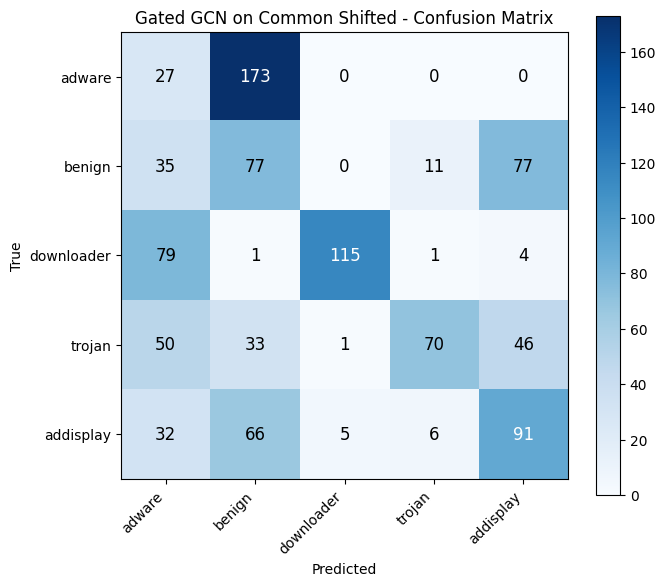

gated standard: 0.7170, shifted: 0.3800, gap: 0.3370


('results/gated_shifted_metrics.json', 'results/gated_shifted_results.csv')

In [12]:
# reset train transform back to zero-fill since the prune cell mutated it
# (train_loader_e holds a live reference to ds_e_train, so transform change leaks)
ds_e_train.transform = make_missingness_transform(ENRICHED_GROUPS, drop_prob=DROP_PROB, strategy="zero", seed=SEED)
g = torch.Generator(); g.manual_seed(SEED)
train_loader_g = DataLoader(ds_e_train, batch_size=BATCH_SIZE, shuffle=True, generator=g)

m_gated = GatedGCN(
    ds_e_train.num_features, HIDDEN_DIM, ds_e_train.num_classes, num_groups=len(ENRICHED_GROUPS)
).to(device)
t0 = time.time()
m_gated, _, _, best_val_g = train_model_gated(m_gated, train_loader_g, val_loader_e, EPOCHS, LR, device)
t_gated = time.time() - t0

preds_gs, labels_gs = predict_gated(m_gated, test_loader_e, device)
acc_gs = accuracy_score(labels_gs, preds_gs)

# defensive: re-attach all-ones missingness mask in case shifted_enriched got rebuilt
for d in shifted_enriched:
    if not hasattr(d, "missingness_mask"):
        d.missingness_mask = torch.ones(1, len(ENRICHED_GROUPS))
shifted_loader_g = make_shifted_loader(shifted_enriched, batch_size=BATCH_SIZE)
preds_gsh, labels_gsh = predict_gated(m_gated, shifted_loader_g, device)
acc_gsh = accuracy_score(labels_gsh, preds_gsh)

# confusion matrix for gated model on shifted set (paper figure)
cm = confusion_matrix(labels_gsh, preds_gsh)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Gated GCN on Common Shifted - Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=12)
fig.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "gated_shifted_confusion_matrix.png"), dpi=150)
plt.show()

gap_g = compute_robustness_gap(acc_gs, acc_gsh)
print(f"gated standard: {acc_gs:.4f}, shifted: {acc_gsh:.4f}, gap: {gap_g:.4f}")

config = {"feature_type": "enriched", "missingness_strategy": "zero_with_gating", "epochs": EPOCHS, "device": str(device)}
metrics = build_metrics(preds_gsh, labels_gsh, CLASS_NAMES, config, best_val_g, t_gated)
metrics["robustness_gap"] = gap_g
metrics["accuracy_standard"] = round(float(acc_gs), 4)
save_metrics(metrics, RESULTS_DIR, prefix="gated_shifted")


## 9. Robustness Gap Comparison Bar Chart


                model  standard  shifted   gap
baseline (structural)     0.746    0.384 0.362
 enriched (zero-fill)     0.737    0.412 0.325
     enriched (prune)     0.738    0.428 0.310
        gated (novel)     0.717    0.380 0.337


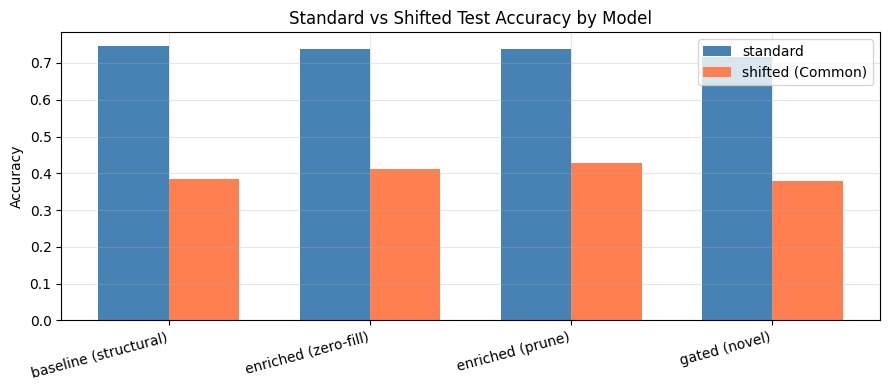

saved results/robustness_summary.csv


In [13]:
import pandas as pd

rows = [
    ("baseline (structural)", acc_standard, acc_shifted, gap),
    ("enriched (zero-fill)", acc_es, acc_esh, gap_e),
    ("enriched (prune)", acc_eps, acc_epsh, gap_ep),
    ("gated (novel)", acc_gs, acc_gsh, gap_g),
]
df = pd.DataFrame(rows, columns=["model", "standard", "shifted", "gap"])
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df))
width = 0.35
ax.bar(x - width/2, df["standard"], width, label="standard", color="steelblue")
ax.bar(x + width/2, df["shifted"], width, label="shifted (Common)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(df["model"], rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Standard vs Shifted Test Accuracy by Model")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "robustness_gap_bar.png"), dpi=150)
plt.show()

df.to_csv(os.path.join(RESULTS_DIR, "robustness_summary.csv"), index=False)
print("saved", os.path.join(RESULTS_DIR, "robustness_summary.csv"))


## Summary

Four models trained on standard MalNet-Tiny, evaluated on both standard and the Common shifted test set. The robustness gap column tells us which model holds up best under covariate shift. These are the numbers that go into the paper.
